Counts by source/day:
source  main  mine
day               
3        475   475
6        475   475
8        473   473
10       470   470
13       467   467
15       462   462
17       461   461
20       466   466
24       475   475
28       474   474
30       470   470

Area summary by source/day:
            count          mean   median  min      max
source day                                            
main   3      475   3020.256842   3048.0  0.0   6767.0
       6      475   4039.623158   4086.0  0.0   7367.0
       8      473   3356.644820   3610.0  0.0   9959.0
       10     470   4300.719149   4382.5  0.0   8209.0
       13     467   7496.792291   7472.0  0.0  17065.0
       15     462   9425.049784   9153.0  0.0  16841.0
       17     461  11877.082430  11554.0  0.0  22797.0
       20     466  15329.034335  14445.0  0.0  43105.0
       24     475  18456.972632  17774.0  0.0  47172.0
       28     474  23234.677215  21740.0  0.0  79108.0
       30     470  25492.195745  23382.0  

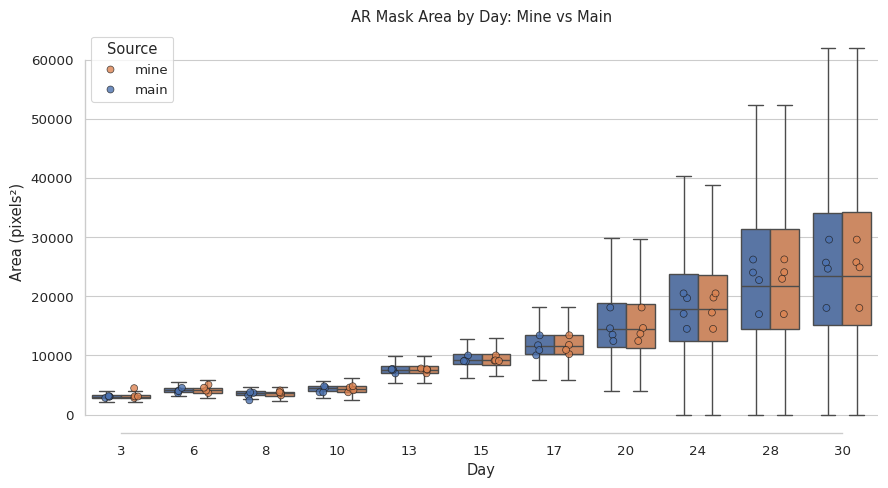

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.io import imread


MINE_JSON = Path("/net/projects2/promega/2026_04_non_env/project_data/amanda_test/images/image_map_resized_512x384_predicted_overlay_ar_meanfill.json")
MAIN_JSON = Path("/net/projects2/promega/2026_04_15_data/intermediate/indexes/image_map_resized_512x384_predicted_overlay_ar_meanfill.json")

# Change this if you know the actual micron-per-pixel scale.
# If unknown, keep 1.0 and interpret area as pixel area.
PIXEL_SIZE_UM = 1.0


def parse_day(s):
    s = str(s)
    m = re.search(r"Dy\s*_?(\d+)", s, flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan


def parse_batch(s):
    s = str(s)
    m = re.search(r"(BA\d+)", s, flags=re.IGNORECASE)
    return m.group(1) if m else "unknown"


def canonical_id(s):
    s = str(s)
    s = Path(s).stem
    s = s.replace("_nostitch", "")
    s = s.replace("_clipped_meanfill_auto_filled", "")
    s = s.replace(" ", "_")
    s = re.sub(r"_+", "_", s)
    return s


def get_meanfill_block(entry):
    for k, v in entry.items():
        if k.startswith("clipped_meanfill"):
            return k, v
    return None, {}


def mask_area(mask_path):
    mask_path = Path(mask_path)
    if not mask_path.exists():
        return np.nan

    m = imread(str(mask_path))
    if m.ndim == 3:
        m = m[:, :, 0]

    area_px = int((m > 127).sum())
    area_um2 = area_px * (PIXEL_SIZE_UM ** 2)
    return area_um2


def load_area_df(json_path, label):
    mapping = json.loads(json_path.read_text())
    rows = []

    for rid, entry in mapping["entries"].items():
        mf_key, mf = get_meanfill_block(entry)

        # Best source: the exact AR mask used by meanfill
        mask_path = mf.get("cm_source_mask_abs")

        # Fallbacks if source path was not recorded
        if not mask_path:
            mask_path = entry.get("ar_mask_abs") or entry.get("ar_mask")

        if not mask_path:
            continue

        id_string = entry.get("main_id") or rid or mask_path

        area_um2 = mask_area(mask_path)

        rows.append({
            "source": label,
            "record_id": rid,
            "main_id": entry.get("main_id"),
            "canonical_id": canonical_id(id_string),
            "batch": parse_batch(id_string),
            "day": parse_day(id_string),
            "mask_path": str(mask_path),
            "area_um2": area_um2,
        })

    return pd.DataFrame(rows)


df_mine = load_area_df(MINE_JSON, "mine")
df_main = load_area_df(MAIN_JSON, "main")

df_compare = pd.concat([df_mine, df_main], ignore_index=True)
df_compare = df_compare.dropna(subset=["day", "area_um2"])
df_compare["day"] = df_compare["day"].astype(int)

print("Counts by source/day:")
print(df_compare.groupby(["source", "day"]).size().unstack("source"))

print("\nArea summary by source/day:")
print(
    df_compare
    .groupby(["source", "day"])["area_um2"]
    .agg(["count", "mean", "median", "min", "max"])
)

# Batch-day means
means = (
    df_compare
    .groupby(["source", "batch", "day"], as_index=False)["area_um2"]
    .mean()
)

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    data=df_compare,
    x="day",
    y="area_um2",
    hue="source",
    showfliers=False,
)

sns.stripplot(
    data=means,
    x="day",
    y="area_um2",
    hue="source",
    dodge=True,
    marker="o",
    size=5,
    edgecolor="k",
    linewidth=0.5,
    alpha=0.8,
    ax=ax,
)

ax.set_title("AR Mask Area by Day: Mine vs Main")
ax.set_ylabel("Area (µm²)" if PIXEL_SIZE_UM != 1.0 else "Area (pixels²)")
ax.set_xlabel("Day")

# Clean duplicate legends from boxplot + stripplot
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Source", loc="upper left")

sns.despine(trim=True)
plt.tight_layout()
plt.show()

MAIN matches:
3 BA1 96_1 Dy03 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy03_A10_clipped_meanfill_auto_filled.png
6 BA1 96_1 Dy06 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy06_A10_clipped_meanfill_auto_filled.png
8 BA1 96_1 Dy08 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy08_A10_clipped_meanfill_auto_filled.png
10 BA1 96_1 Dy10 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy10_A10_clipped_meanfill_auto_filled.png
13 BA1 96_1 Dy13 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy13_A10_clipped_meanfill_auto_filled.png
15 BA1 96_1 Dy15 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy15_A10_clipped_meanfill_auto_filled.png
17 BA1 96_1 Dy17 A10 /net/projects2/promega/2026_04_15_data/intermediate/mean_fill_clip/BA1_96_1_Dy17_A10_clipped_meanfill_auto_filled.png
20 BA1 96_1 Dy20

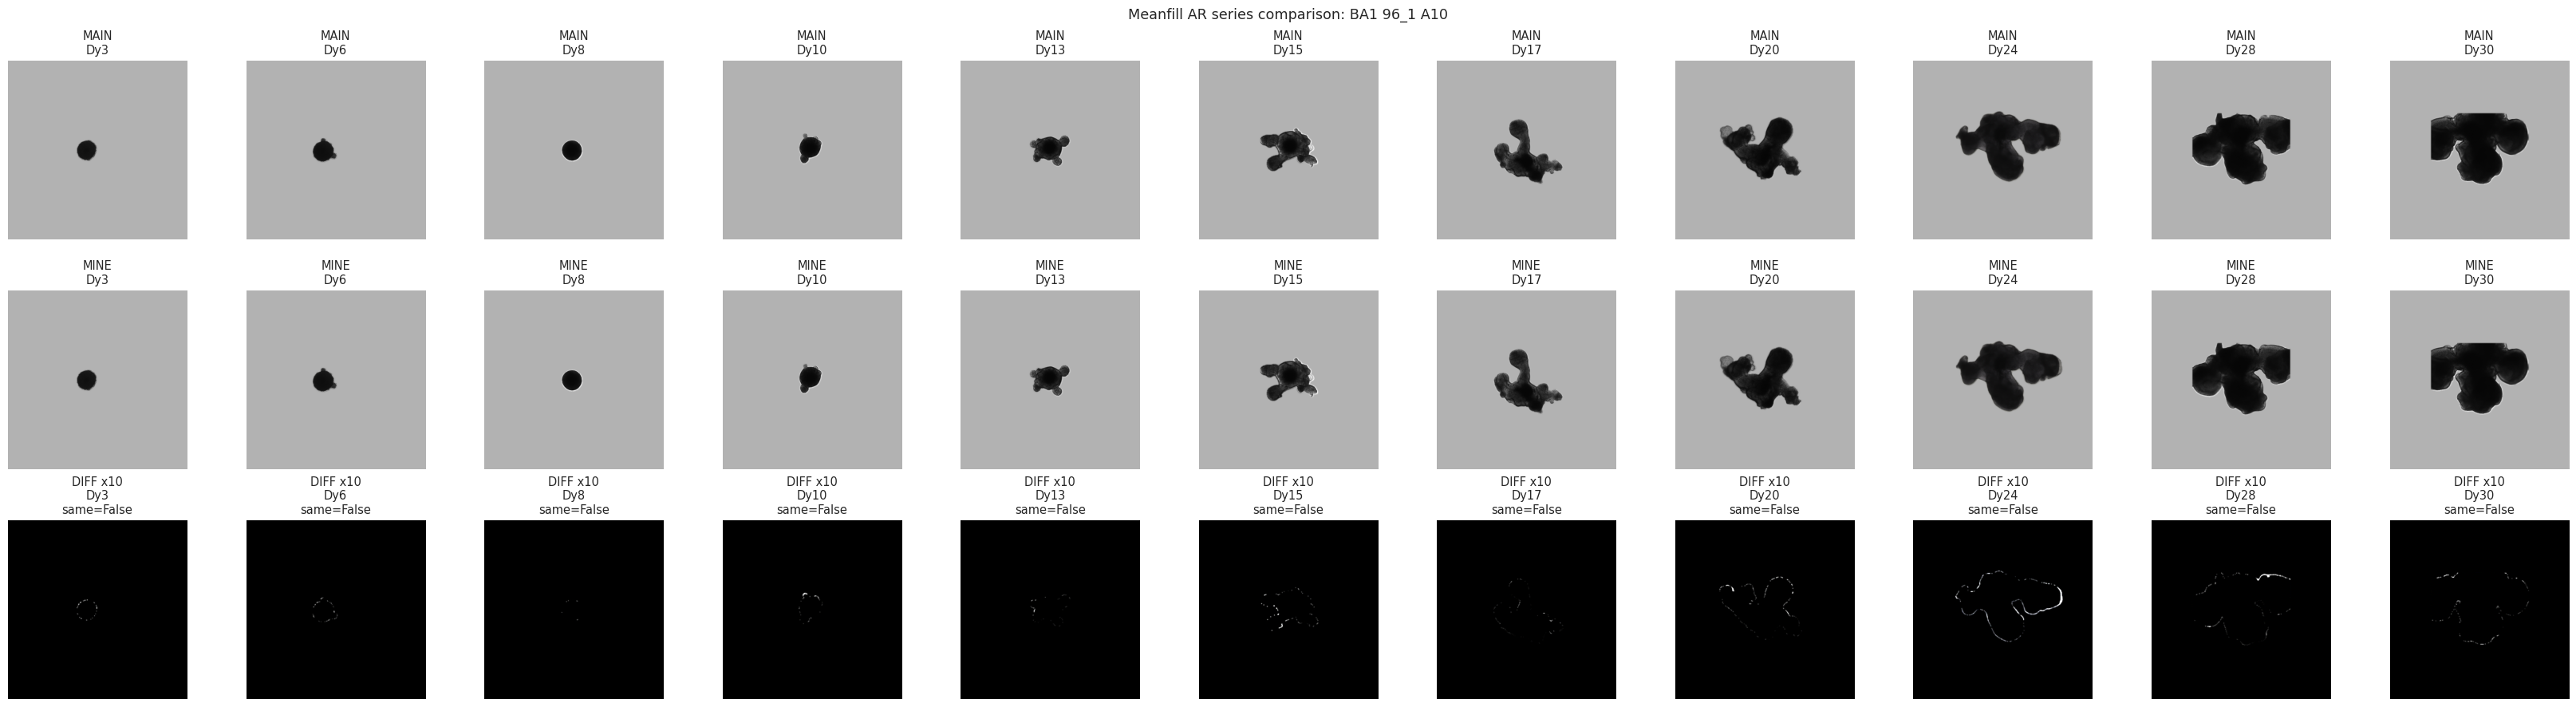

In [9]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

MINE_JSON = Path("/net/projects2/promega/2026_04_non_env/project_data/amanda_test/images/image_map_resized_512x384_predicted_overlay_ar_meanfill.json")
MAIN_JSON = Path("/net/projects2/promega/2026_04_15_data/intermediate/indexes/image_map_resized_512x384_predicted_overlay_ar_meanfill.json")

BATCH = "BA1"
PLATE = "96_1"
WELL = "A10"

SAVE_PATH = Path(f"/net/projects2/promega/2026_04_non_env/project_data/amanda_test/series_tests/series_compare_{BATCH}_{PLATE}_{WELL}.png")


def parse_day(s):
    m = re.search(r"Dy\s*_?(\d+)", str(s), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None


def parse_record_parts(s):
    """
    Expected-ish:
    BA2 96_1 Dy24 B5
    BA2_96_1_Dy24_B5
    """
    s = str(s).replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()

    batch = re.search(r"\b(BA\d+)\b", s, flags=re.IGNORECASE)
    day = re.search(r"\bDy\s*(\d+)\b", s, flags=re.IGNORECASE)
    well = re.search(r"\b([A-H]\d{1,2})\b", s, flags=re.IGNORECASE)

    # plate is awkward because 96_1 becomes "96 1" after replacing underscores
    plate_match = bool(re.search(r"\b96\s*1\b", s))

    return {
        "batch": batch.group(1).upper() if batch else None,
        "day": int(day.group(1)) if day else None,
        "well": well.group(1).upper() if well else None,
        "plate_match": plate_match,
    }


def get_meanfill_block(entry):
    for k, v in entry.items():
        if k.startswith("clipped_meanfill"):
            return k, v
    return None, {}


def collect_series(json_path, label, batch, plate, well):
    mapping = json.loads(json_path.read_text())
    rows = []

    for rid, entry in mapping["entries"].items():
        mf_key, mf = get_meanfill_block(entry)
        if not mf:
            continue

        text = " | ".join([
            str(rid),
            str(entry.get("main_id")),
            str(mf.get("cm_image_abs")),
            str(mf.get("cm_source_image_abs")),
            str(mf.get("cm_source_mask_abs")),
        ])

        parts = parse_record_parts(rid)

        if parts["batch"] != batch.upper():
            continue
        if parts["well"] != well.upper():
            continue

        # optional plate check
        if plate == "96_1" and not parts["plate_match"]:
            continue

        rows.append({
            "source": label,
            "rid": rid,
            "day": parts["day"],
            "img_path": mf.get("cm_image_abs"),
            "src_img_path": mf.get("cm_source_image_abs"),
            "src_mask_path": mf.get("cm_source_mask_abs"),
        })

    return sorted(rows, key=lambda x: (999 if x["day"] is None else x["day"], x["rid"]))


mine_rows = collect_series(MINE_JSON, "mine", BATCH, PLATE, WELL)
main_rows = collect_series(MAIN_JSON, "main", BATCH, PLATE, WELL)

print("MAIN matches:")
for r in main_rows:
    print(r["day"], r["rid"], r["img_path"])

print("\nMINE matches:")
for r in mine_rows:
    print(r["day"], r["rid"], r["img_path"])

if not main_rows and not mine_rows:
    raise ValueError(f"No matches found for {BATCH} {PLATE} {WELL}")

main_by_day = {r["day"]: r for r in main_rows if r["day"] is not None}
mine_by_day = {r["day"]: r for r in mine_rows if r["day"] is not None}
all_days = sorted(set(main_by_day) | set(mine_by_day))

print("\nDays found:", all_days)

print("\nPer-day exact image comparison:")
for day in all_days:
    r_main = main_by_day.get(day)
    r_mine = mine_by_day.get(day)

    if r_main is None or r_mine is None:
        print(f"Dy{day}: missing in {'main' if r_main is None else 'mine'}")
        continue

    a = imread(r_main["img_path"])
    b = imread(r_mine["img_path"])

    same_shape = a.shape == b.shape
    same_pixels = same_shape and np.array_equal(a, b)

    if same_shape:
        mad = np.mean(np.abs(a.astype(np.int16) - b.astype(np.int16)))
        maxdiff = np.max(np.abs(a.astype(np.int16) - b.astype(np.int16)))
    else:
        mad = np.nan
        maxdiff = np.nan

    print(
        f"Dy{day}: exact_same={same_pixels}, "
        f"shape_main={a.shape}, shape_mine={b.shape}, "
        f"mean_abs_diff={mad:.6f}, max_abs_diff={maxdiff}"
    )


ncols = len(all_days)
fig, axes = plt.subplots(3, ncols, figsize=(3.0 * ncols, 9.0), squeeze=False)

for col, day in enumerate(all_days):
    r_main = main_by_day.get(day)
    r_mine = mine_by_day.get(day)

    ax = axes[0, col]
    if r_main and r_main["img_path"] and Path(r_main["img_path"]).exists():
        ax.imshow(imread(r_main["img_path"]))
        ax.set_title(f"MAIN\nDy{day}")
    else:
        ax.text(0.5, 0.5, f"MAIN\nDy{day}\nmissing", ha="center", va="center")
    ax.axis("off")

    ax = axes[1, col]
    if r_mine and r_mine["img_path"] and Path(r_mine["img_path"]).exists():
        ax.imshow(imread(r_mine["img_path"]))
        ax.set_title(f"MINE\nDy{day}")
    else:
        ax.text(0.5, 0.5, f"MINE\nDy{day}\nmissing", ha="center", va="center")
    ax.axis("off")

    ax = axes[2, col]
    if (
        r_main and r_mine
        and r_main["img_path"] and r_mine["img_path"]
        and Path(r_main["img_path"]).exists()
        and Path(r_mine["img_path"]).exists()
    ):
        a = imread(r_main["img_path"]).astype(np.int16)
        b = imread(r_mine["img_path"]).astype(np.int16)

        if a.shape == b.shape:
            diff = np.abs(a - b)
            diff_vis = np.clip(diff * 10, 0, 255).astype(np.uint8)
            same = np.array_equal(a, b)
            ax.imshow(diff_vis)
            ax.set_title(f"DIFF x10\nDy{day}\nsame={same}")
        else:
            ax.text(0.5, 0.5, "shape mismatch", ha="center", va="center")
    else:
        ax.text(0.5, 0.5, f"DIFF\nDy{day}\nmissing", ha="center", va="center")
    ax.axis("off")

plt.suptitle(f"Meanfill AR series comparison: {BATCH} {PLATE} {WELL}", y=0.98)
plt.tight_layout()
#plt.savefig(SAVE_PATH, dpi=200, bbox_inches="tight")
print("\nSaved montage to:", SAVE_PATH)
plt.show()

Index(['img_id', 'batch', 'day', 'batch_day', 'area_um2', 'perimeter_um',
       'major_um', 'minor_um', 'circularity', 'solidity', 'convexity',
       'aspect_ratio', 'xor_curve', 'marginal_diff', 'cumulative_diff',
       'entropy'],
      dtype='object')
              img_id  batch  day     batch_day       area_um2  perimeter_um  \
0   BA3 96_1 Dy15 A1      3   15  batch3_day15  963066.169624   4464.759978   
1  BA3 96_1 Dy15 A10      3   15  batch3_day15  707353.764648   3367.475244   
2  BA3 96_1 Dy15 A11      3   15  batch3_day15  698913.748138   3234.611558   
3  BA3 96_1 Dy15 A12      3   15  batch3_day15  743876.931332   3558.344570   
4   BA3 96_1 Dy15 A2      3   15  batch3_day15  631242.901478   3586.991205   

      major_um    minor_um  circularity  solidity  convexity  aspect_ratio  \
0  1689.726229  779.235260     0.607113  0.893581   0.944258      2.168442   
1  1078.210370  863.807337     0.783859  0.960502   0.988816      1.248207   
2   986.116085  911.096232     0.

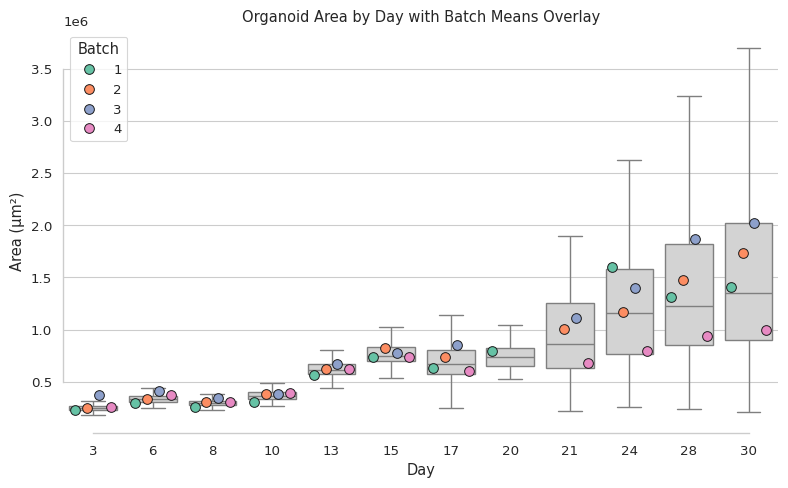

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd

print(df.columns)
print(df.head())

# Extract BA (e.g., BA4) and Day (e.g., 03)
# df["batch"] = df["batch_day"].str.extract(r"(BA\d)")
# df["day"]   = df["batch_day"].str.extract(r"Dy(\d{2})").astype(int)
# print(df[["batch_day", "batch", "day"]].drop_duplicates())

# --- Step 4: Compute batch-day means for overlay ---
metric = "area_um2"
means = df.groupby(["batch", "day"])[metric].mean().reset_index()

# --- Step 5: Plot ---
sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8, 5))

# A) Boxplot of all values by day (no hue)
ax = sns.boxplot(data=df, x="day", y=metric, color="lightgray", showfliers=False)

# B) Overlay batch-wise mean values as dots
sns.stripplot(
    data=means,
    x="day", y=metric, hue="batch",
    dodge=True, palette="Set2",
    size=7, marker="o", edgecolor="k", linewidth=0.7,
    ax=ax
)

# --- Final formatting ---
ax.set_title("Organoid Area by Day with Batch Means Overlay")
ax.set_ylabel("Area (µm²)")
ax.set_xlabel("Day")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()


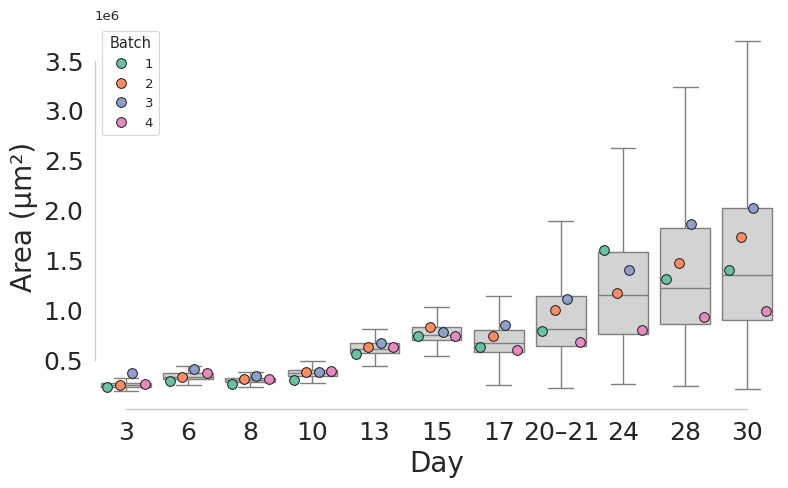

In [9]:
# --- Step 0: collapse day 20 & 21 into one category ---
df = df.copy()
df["day_group"] = df["day"].astype(int)
df.loc[df["day_group"].isin([20, 21]), "day_group"] = 20  # sentinel
df["day_group"] = df["day_group"].map(lambda d: "20–21" if d == 20 else str(d))

# order on the x-axis: … 18, 19, 20–21, 22, 23 …
days_num = sorted(df.loc[~df["day"].astype(int).isin([20, 21]), "day"].astype(int).unique())
day_order = [*(str(d) for d in days_num if d < 20), "20–21", *(str(d) for d in days_num if d > 21)]

# --- Step 4: Compute batch-day means for overlay (using day_group) ---
metric = "area_um2"
means = df.groupby(["batch", "day_group"])[metric].mean().reset_index()

# --- Step 5: Plot ---
sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.figure(figsize=(8, 5))

# A) Boxplot by collapsed day_group
ax = sns.boxplot(data=df, x="day_group", y=metric, order=day_order,
                 color="lightgray", showfliers=False)

# B) Overlay batch-wise means as dots
sns.stripplot(
    data=means, x="day_group", y=metric, hue="batch", dodge=True,
    palette="Set2", size=7, marker="o", edgecolor="k", linewidth=0.7,
    order=day_order, ax=ax
)

#ax.set_title("Organoid Area by Day")
ax.set_ylabel("Area (µm²)", fontsize=20)
ax.set_xlabel("Day", fontsize=20)
#ax.set_xticks(fontsize=18)
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(False)
plt.tight_layout()
plt.show()


In [17]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
# Load original mapping JSON
with open("/net/projects2/promega/data-analysis/output/image_mapping.json") as f:
    mapping = json.load(f)

# Convert to DataFrame
meta_df = pd.DataFrame.from_dict(mapping, orient="index")
meta_df["img_id"] = meta_df.index

# Merge treatment and cellLine into df
df = df.merge(meta_df[["img_id", "treatment", "cellLine"]], on="img_id", how="left")





In [18]:
df_with_treatment = df[df["treatment"].notna()]
df_no_treatment = df[df["treatment"].isna()]

df_kp9_treat     = df[(df["cellLine"] == "KP9") & (df["treatment"].notna())]
df_kp9_control   = df[(df["cellLine"] == "KP9") & (df["treatment"].isna())]

df_gm_treat      = df[(df["cellLine"] == "GM23279A") & (df["treatment"].notna())]
df_gm_control    = df[(df["cellLine"] == "GM23279A") & (df["treatment"].isna())]


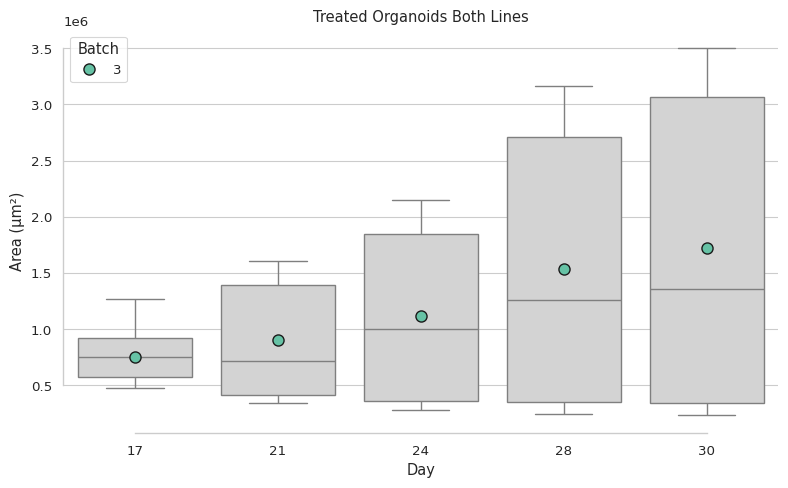

In [19]:
metric = "area_um2"
df_treated = df[df["treatment"].notna()]

means_treated = df_treated.groupby(["batch", "day"])[metric].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_treated, x="day", y=metric,
    color="lightgray", showfliers=False
)

sns.stripplot(
    data=means_treated, x="day", y=metric,
    hue="batch", dodge=True, palette="Set2",
    size=8, marker="o", edgecolor="k", linewidth=1, ax=ax
)

ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Treated Organoids Both Lines")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()



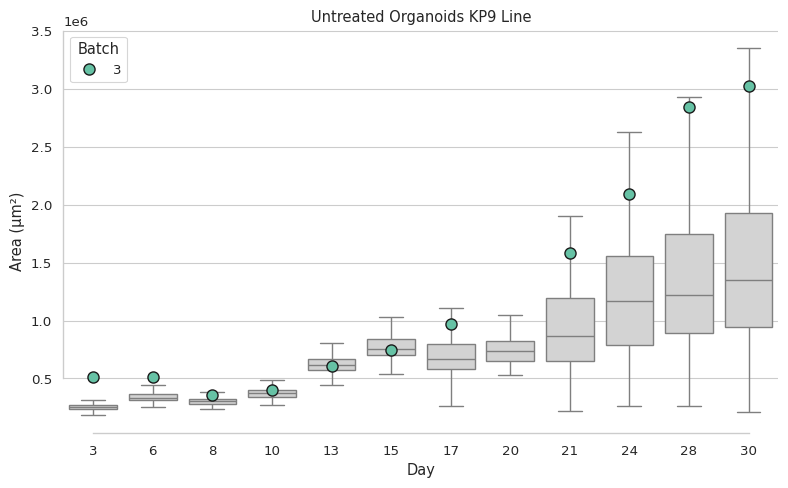

In [20]:
df_untreated = df[df["treatment"].isna()]
means_untreated = df_kp9_control.groupby(["batch", "day"])[metric].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_untreated, x="day", y=metric,
    color="lightgray", showfliers=False
)

sns.stripplot(
    data=means_untreated, x="day", y=metric,
    hue="batch", dodge=True, palette="Set2",
    size=8, marker="o", edgecolor="k", linewidth=1, ax=ax
)

ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Untreated Organoids KP9 Line")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()


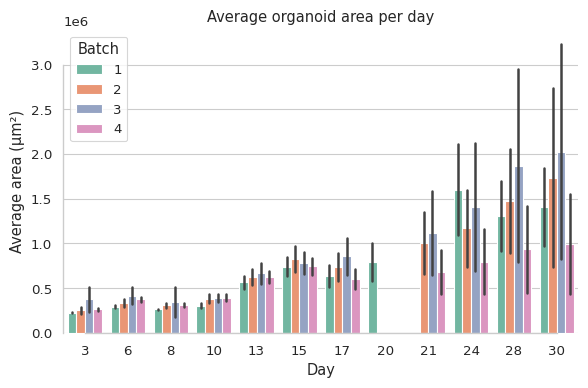

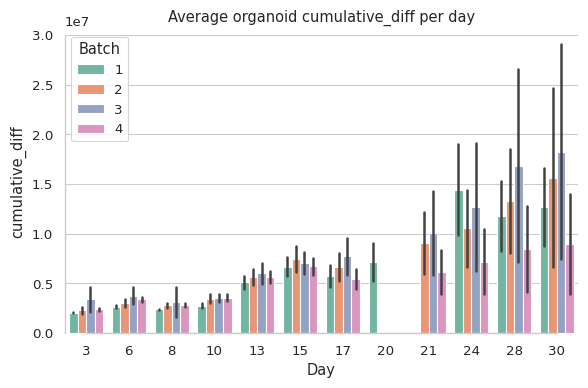

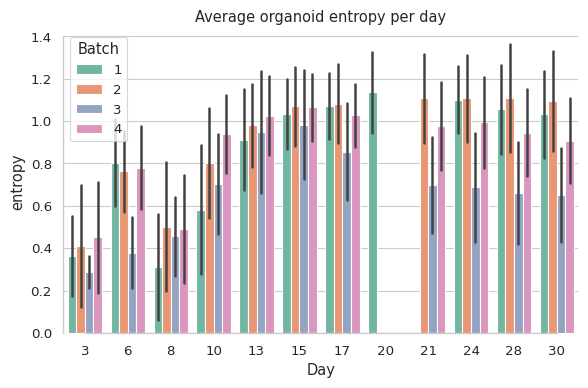

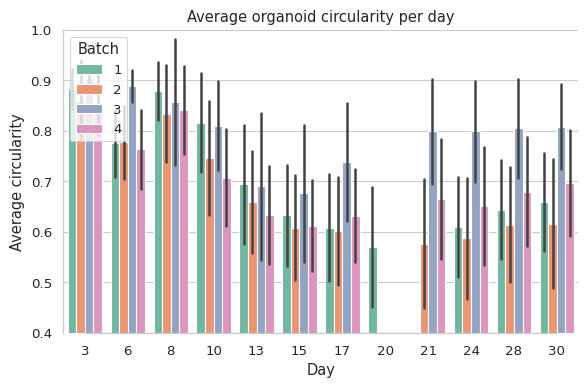

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Seaborn theme
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="DejaVu Sans",
    font_scale=1.1
)

# Function for bar plots
def plot_bar(metric, ylabel, title, ylim=None):
    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=df, x="day", y=metric, hue="batch",
        errorbar="sd", palette="Set2"
    )
    plt.ylabel(ylabel)
    plt.xlabel("Day")
    plt.title(title)
    if ylim:
        plt.ylim(ylim)
    plt.legend(title="Batch", loc="upper left")
    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

# Plotting
plot_bar("area_um2", "Average area (µm²)", "Average organoid area per day")
plot_bar("cumulative_diff", "cumulative_diff", "Average organoid cumulative_diff per day")
plot_bar("entropy", "entropy", "Average organoid entropy per day")
plot_bar("circularity", "Average circularity", "Average organoid circularity per day", ylim=(0.4, 1))


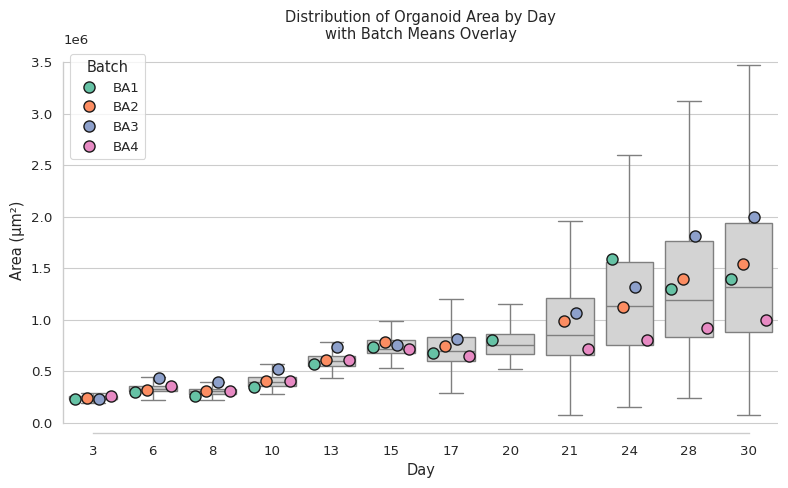

In [5]:


metric = "area_um2"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("Area (µm²)")
ax.set_title("Distribution of Organoid Area by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

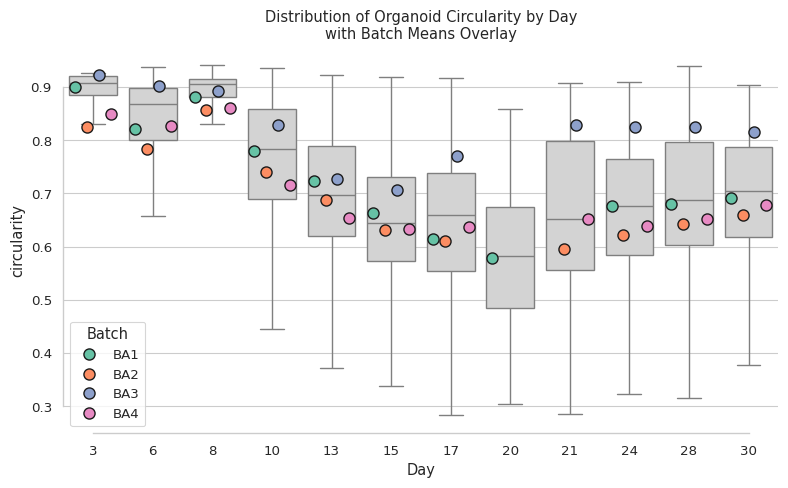

In [8]:
metric = "circularity"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("circularity")
ax.set_title("Distribution of Organoid Circularity by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="lower left")
plt.tight_layout()
plt.show()

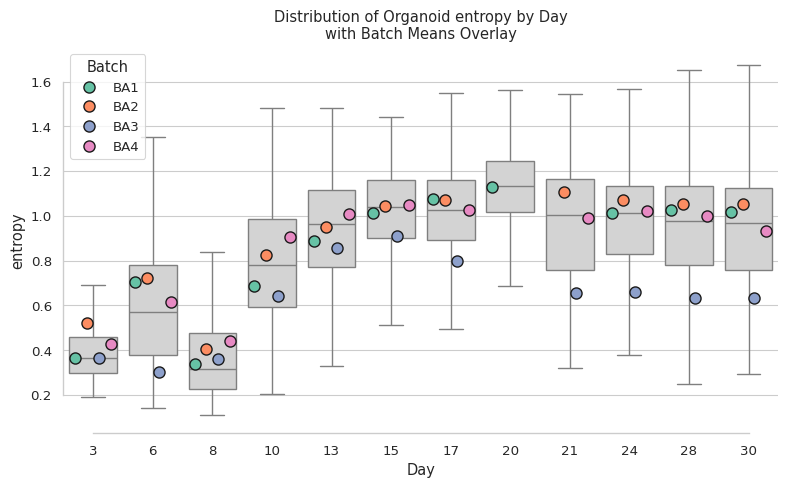

In [9]:
metric = "entropy"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))

# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("entropy")
ax.set_title("Distribution of Organoid entropy by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
# print how many rows are in df
print(f"Number of rows in df: {len(df)}")

Number of rows in df: 5165


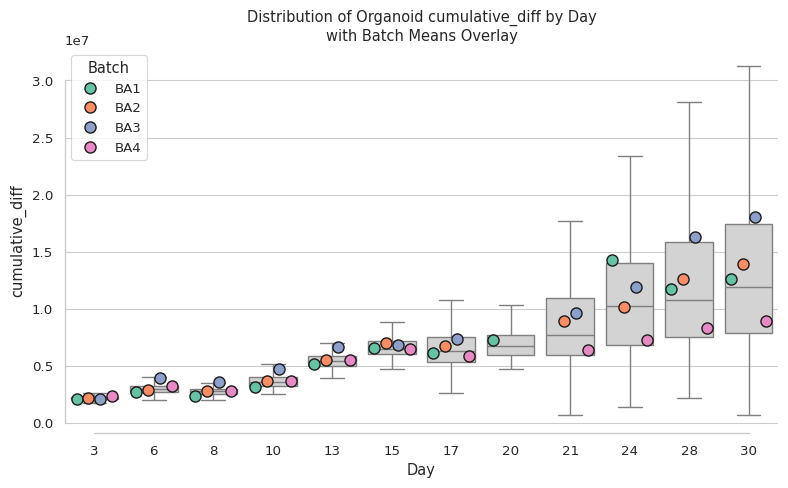

In [8]:
metric = "cumulative_diff"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
sns.set_theme(context="paper", style="whitegrid", palette="Set2", font="sans-serif", font_scale=1.1)
plt.figure(figsize=(8,5))


# A) The grey boxplot of *all* measurements by day
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) Overlay batch means with dodge=True so they align under each day
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    palette="Set2",
    dodge=True,        # align under each day
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Final touches
ax.set_xlabel("Day")
ax.set_ylabel("cumulative_diff")
ax.set_title("Distribution of Organoid cumulative_diff by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()

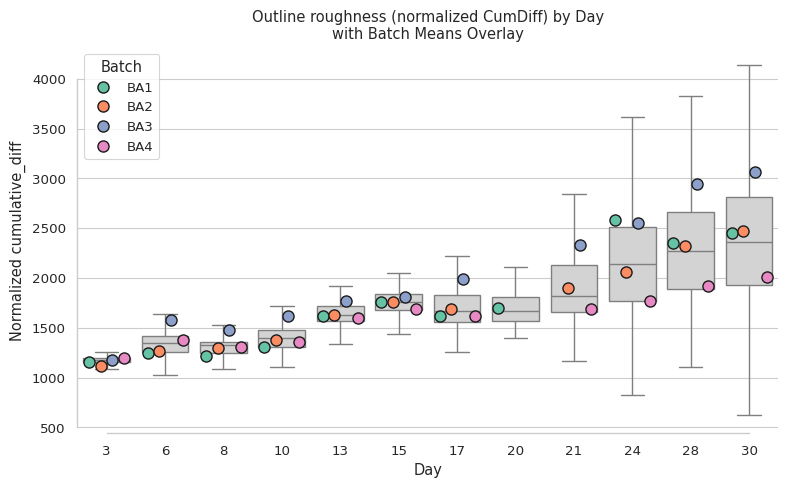

In [9]:
# 0) Normalize
df["norm_cumdiff"] = df["cumulative_diff"] / df["perimeter_um"]

# 1) Choose metric
metric = "norm_cumdiff"

# 2) Compute batch‐day means
means = df.groupby(["batch","day"])[metric].mean().reset_index()

# 3) Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="Set2",
    font="sans-serif",
    font_scale=1.1
)

plt.figure(figsize=(8,5))

# A) grey boxplot of *all* data
ax = sns.boxplot(
    data=df,
    x="day", y=metric,
    color="lightgray",
    showfliers=False
)

# B) overlay batch means
sns.stripplot(
    data=means,
    x="day", y=metric,
    hue="batch",
    dodge=True,
    size=8,
    marker="o",
    edgecolor="k",
    linewidth=1,
    ax=ax
)

# 4) Polish
ax.set_xlabel("Day")
ax.set_ylabel("Normalized cumulative_diff")
ax.set_title("Outline roughness (normalized CumDiff) by Day\nwith Batch Means Overlay")
sns.despine(trim=True)
plt.legend(title="Batch", loc="upper left")
plt.tight_layout()
plt.show()
